# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
# Клонируем свой форк репозитория с GitHub
!git clone https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse.git

Cloning into '2025-Selyutin-TimeSeriesCourse'...
remote: Enumerating objects: 302, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 302 (delta 16), reused 3 (delta 3), pack-reused 234 (from 2)
Receiving objects: 100% (302/302), 242.73 MiB | 14.48 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Updating files: 100% (198/198), done.


In [2]:
%cd 2025-Selyutin-TimeSeriesCourse/practice/"06 Chains"

/content/2025-Selyutin-TimeSeriesCourse/practice/06 Chains


In [3]:
!ls

'06 Chains.ipynb'   datasets


## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

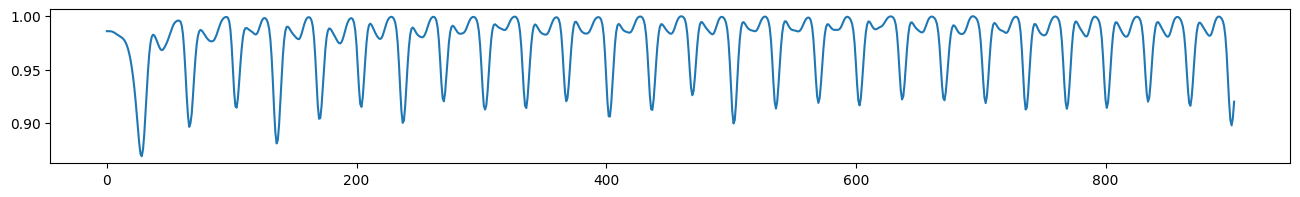

In [5]:
fig, ax = plt.subplots(figsize=(16, 2))
ts = np.loadtxt('datasets/Rotation Matrix.txt')
ax.plot(ts)

In [12]:
# INSERT YOUR CODE
#  Длина окна
m = 50

# Матричный профиль
mp = stumpy.stump(ts, m)



In [14]:
# Извлекаем P и I
P = mp[:, 0]
I = mp[:, 1].astype(int)

n_subseq = len(P)

# Функция для построения цепочки
def build_chain_from_seed(seed, I, m, require_time_order=False):
    chain = [int(seed)]
    seen = set(chain)
    current = int(seed)
    while True:
        nbr = int(I[current])
        if nbr in seen or abs(nbr - current) < m:
            break
        if require_time_order and nbr <= current:
            break
        chain.append(nbr)
        seen.add(nbr)
        current = nbr
    return chain

# Построим цепочки для всех стартов и выберем самую длинную
best_chain_undirected = []
best_chain_timeordered = []

for s in range(n_subseq):
    c1 = build_chain_from_seed(s, I, m, require_time_order=False)
    if len(c1) > len(best_chain_undirected):
        best_chain_undirected = c1
    c2 = build_chain_from_seed(s, I, m, require_time_order=True)
    if len(c2) > len(best_chain_timeordered):
        best_chain_timeordered = c2

print("Самая длинная цепочка (без требования временного порядка):")
print(best_chain_undirected)
print("Длина:", len(best_chain_undirected))

print("\nСамая длинная цепочка (требуя монотонности по времени):")
print(best_chain_timeordered)
print("Длина:", len(best_chain_timeordered))

Самая длинная цепочка (без требования временного порядка):
[0, 109, 475, 210, 610]
Длина: 5

Самая длинная цепочка (требуя монотонности по времени):
[306, 573, 674, 739, 804]
Длина: 5


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Эволюционирующий шаблон - это последовательность похожих подпоследовательностей, которые повторяются в ряде, возможно, с некоторыми изменениями, но сохраняют общую форму.

Цепочка мотивов строится следующим образом:
1) Начинаем с некоторого стартового индекса подпоследовательности.  
2) Идём по ссылкам I, добавляя в цепочку ближайшие соседи.  
3) Можно требовать монотонность по времени, чтобы цепочка отражала последовательное повторение паттерна в ряде.  
4) Ограничение: подпоследовательности не должны перекрываться (расстояние ≥ длины окна m).

Результат - последовательность индексов, которые образуют эволюционирующий шаблон временного ряда.

Интерпретация результатов:
Каждое число - это индекс начала подпоследовательности в исходном временном ряде.
Длина цепочки - число повторяющихся (или похожих) сегментов.

Пример: для цепочки [306, 573, 674, 739, 804] каждая подпоследовательность длины m=50 начинается в этих точках и обладает высокой схожестью с предыдущими элементами цепочки.

Различие между цепочками:  
Первая цепочка (без требования временного порядка) показывает глобальные совпадения по всему ряду, но индексы могут прыгать назад и вперёд во времени.

Вторая цепочка (монотонная) отражает эволюцию шаблона во времени, т.е. последовательность повторений паттерна в естественном порядке. Это ближе к наблюдаемой динамике процесса.

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

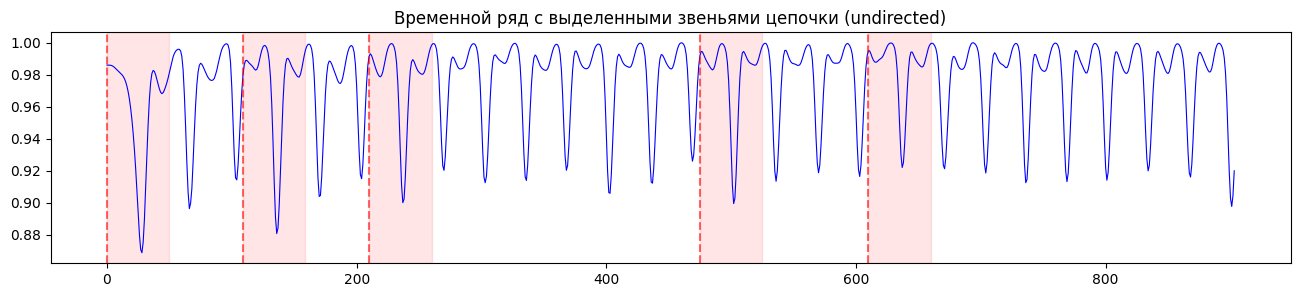

In [16]:
# INSERT YOUR CODE
#  весь временной ряд с выделенными звеньями

fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(ts, color='blue', linewidth=0.8)
for idx in best_chain_undirected:
    # вертикальная линия начала звена
    ax.axvline(idx, color='red', linestyle='--', alpha=0.6)
    # заливка области звена для наглядности
    ax.axvspan(idx, idx+m, color='red', alpha=0.1)
ax.set_title("Временной ряд с выделенными звеньями цепочки (undirected)")
plt.show()

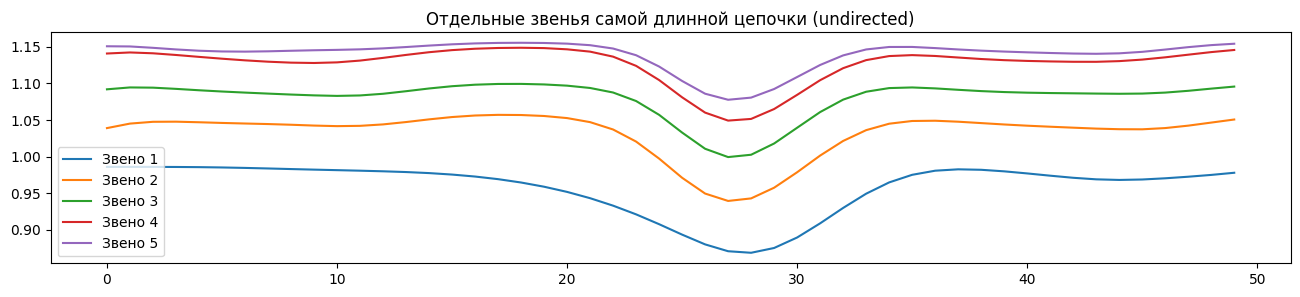

In [17]:

# только сами звенья цепочки

fig, ax = plt.subplots(figsize=(16, 3))
for i, idx in enumerate(best_chain_undirected):
    segment = ts[idx:idx+m]
    # вертикальное смещение для наглядности
    offset = i * 0.5 * (segment.max() - segment.min())
    ax.plot(segment + offset, label=f'Звено {i+1}')
ax.set_title("Отдельные звенья самой длинной цепочки (undirected)")
ax.legend()
plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

График всего временного ряда с выделенными звеньями:  
1) Каждое выделенное звено — это подпоследовательность, которая повторяется или сильно похожа на другие звенья в этой цепочке.  
2) Таким образом, мы визуально видим распределение повторяющегося шаблона во времени.  
3) Там, где появляются вставки, ряд имеет подобные формы, и алгоритм считает их частью одной цепочки.  
Интерпретация: цепочка представляет собой эволюционирующий шаблон - паттерн, который периодически повторяется, хотя конкретные значения могут слегка изменяться.

График отдельных звеньев цепочки:  
На втором графике мы видим только сами звенья, вырезанные из временного ряда.  

Форма звеньев схожа: они имеют общую структуру или сигнатуру паттерна.

Лёгкие различия между звеньями показывают эволюцию шаблона - он повторяется с небольшими вариациями.  

Интерпретация: этот график подтверждает, что найденная цепочка действительно отражает структурно похожие сегменты ряда, а не случайные совпадения. Прогиб в центре звеньев может быть важной характеристикой, которую можно использовать для анализа динамики процесса.  

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

In [ ]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов.